
# 5e. Biodiversity, pollution & environmental health

Fourth of the Chapter 5 (Impact Investing) biodiversity-case-study
notebooks, covering pollution and environmental-health themes.

Topics covered, in order:

1. Dose-response curve families used in ecotoxicology (log-logistic,
   log-normal, Weibull, hormesis)
2. NOAEL/LOAEL toxicological thresholds, illustrated
3. The US EPA Air Quality Index (AQI) and real PM2.5 time series for six
   world cities
4. Pollution research attention and marine-plastic source shares
   (literature/report-derived summary statistics)
5. The global burden of disease attributable to air pollution (GBD data)
6. The economic cost of pollution by country (World Bank data)
7. The EU's circular-economy and waste-target implementation gap
8. Global freshwater withdrawal trends and cross-country water-stress
   indicators

Sections 3 and 6-8 use real data via `pandas.read_excel`
(`data/chap5_world_aqi.xlsx`, `chap5_world_bank_pollution.xlsx`,
`chap5_mejino_pollution.xlsx`, `chap5_freshwater_data.xlsx`). Sections 1, 2,
4 and 5 reproduce the book's illustrative figures/tables from hardcoded
values (search-engine hit counts, MGI/GBD summary statistics) — there is
no underlying dataset to read for these.

**Data-provenance note on section 1**: this section needs several
dose-response helper functions (log-logistic, log-normal, Weibull, and two
hormesis variants) that aren't available as ready-made implementations, so
they're reimplemented here from the standard dose-response model families
they are named after (as used in, e.g., the R `drc` package: log-logistic,
log-normal, Weibull, and the Brain-Cousens/Cedergreen-Ritz-Streibig
hormesis extensions), with a sign convention chosen so response
*increases* with dose for a positive slope parameter (matching this
section's own "Case $\beta>0$"/"Case $\beta<0$" figure). The exact
parameterization used for these functions elsewhere could not be verified
against a reference implementation — this section is illustrative
curve-shape teaching material in the book, not a fit to data, so the
standard textbook formulas reproduce the intended teaching point
faithfully even without a verified match to an unavailable reference.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

DATA_DIR = "../../data"

color_blue    = "#1f77b4"
color_red     = "#d62728"
color_green   = "#2ca02c"
color_violet  = "#9467bd"
color_teal    = "#17becf"
color_orange  = "#ff7f0e"
color_black   = "#000000"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = False



## 1. Dose-response curve families

Reimplementations of the dose-response helper functions described in the
note above. All four share the convention $z = b \cdot \log(x/e)$, with
$e$ the dose giving the curve's inflection point ("EC50"-style location
parameter), $b$ the slope, and $c$/$d$ the lower/upper asymptotes.


In [2]:

def drc_log_logistic(x, e, b, c, d):
    z = b * np.log(x / e)
    return c + (d - c) / (1 + np.exp(-z))

def drc_log_normal(x, e, b, c, d):
    z = b * np.log(x / e)
    return c + (d - c) * norm.cdf(z)

def drc_weibull2(x, e, b, c, d):
    z = b * np.log(x / e)
    return c + (d - c) * (1 - np.exp(-np.exp(z)))

def drc_hormetic1(x, e, b, c, d, f):
    # Brain-Cousens hormesis: a linear stimulatory term lifts the curve
    # above `d` at low doses before the sigmoid decline dominates.
    z = -b * np.log(x / e)
    return c + (d + f * x - c) / (1 + np.exp(z))

def drc_hormetic2(x, e, b, c, d, f, alpha):
    # Cedergreen-Ritz-Streibig hormesis: an exponentially-decaying
    # stimulatory term instead of a linear one.
    z = -b * np.log(x / e)
    return c + (d - c + f * np.exp(-1 / (x ** alpha))) / (1 + np.exp(z))


### 32a — Increasing vs. decreasing dose-response curves

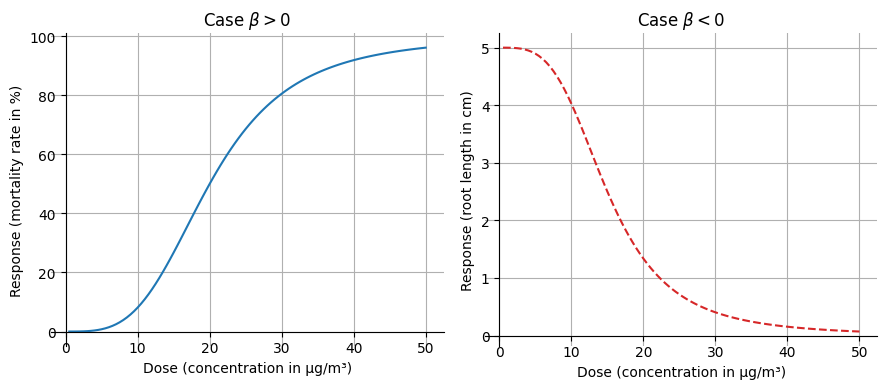

In [3]:

scale = 50
x = scale * np.arange(0.00, 1.001, 0.01)
x = x[x > 0]  # avoid log(0)
y1 = drc_log_logistic(x, 0.40 * scale, 3.5, 0, 100)
y2 = drc_log_logistic(x, 0.30 * scale, -3.5, 0, 5)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].plot(x, y1, "-", color=color_blue, lw=1.5)
axes[0].set_title(r"Case $\beta > 0$")
axes[0].set_xlabel("Dose (concentration in µg/m³)")
axes[0].set_ylabel("Response (mortality rate in %)")

axes[1].plot(x, y2, "--", color=color_red, lw=1.5)
axes[1].set_title(r"Case $\beta < 0$")
axes[1].set_xlabel("Dose (concentration in µg/m³)")
axes[1].set_ylabel("Response (root length in cm)")

for ax in axes:
    ax.grid(True)
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### 32b — Comparing dose-response model families

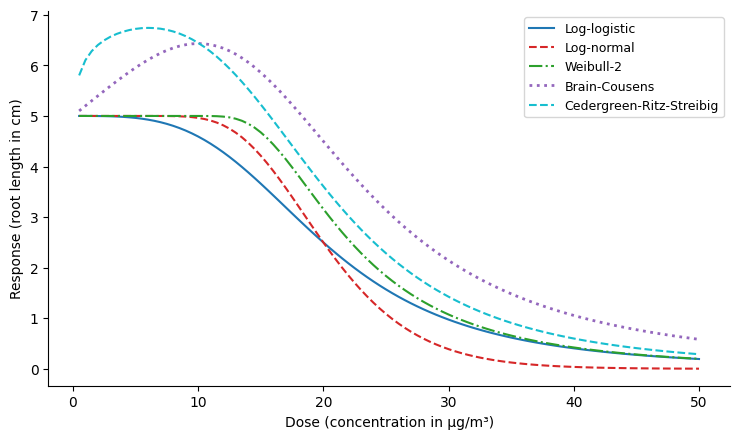

In [4]:

scale = 50
x = scale * np.arange(0.00, 1.001, 0.01)
x = x[x > 0]
y1 = drc_log_logistic(x, 0.40 * scale, -3.5, 0, 5)
y2 = drc_log_normal(x, 0.40 * scale, -3.5, 0, 5)
y3 = drc_weibull2(x, 0.40 * scale, -3.5, 0, 5)
y4 = drc_hormetic1(x, 0.40 * scale, -3.5, 0, 5, 0.2)
y5 = drc_hormetic2(x, 0.40 * scale, -3.5, 0, 5, 3.0, 0.4)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(x, y1, "-", color=color_blue, lw=1.5, label="Log-logistic")
ax.plot(x, y2, "--", color=color_red, lw=1.5, label="Log-normal")
ax.plot(x, y3, "-.", color=color_green, lw=1.5, label="Weibull-2")
ax.plot(x, y4, ":", color=color_violet, lw=2.0, label="Brain-Cousens")
ax.plot(x, y5, "--", color=color_teal, lw=1.5, label="Cedergreen-Ritz-Streibig")
ax.set_xlabel("Dose (concentration in µg/m³)")
ax.set_ylabel("Response (root length in cm)")
ax.legend(fontsize=9, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



### 32c — NOAEL / LOAEL and TC50 / LC50 thresholds

A stylized illustration of the toxicological thresholds regulators use: the
No/Lowest-Observed-Adverse-Effect-Level (NOAEL/LOAEL) from a toxic-effect
curve, and the concentration/lethal-concentration giving a 50% response
(TC50/LC50) from a toxic-effect and a lethal-effect curve respectively.


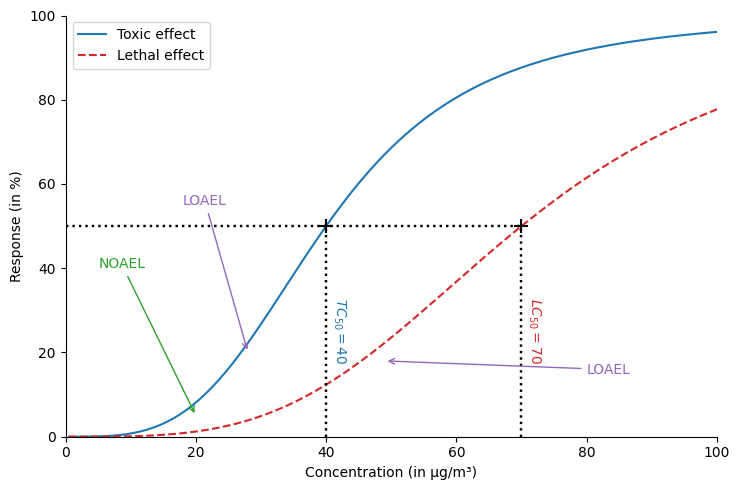

In [5]:

scale = 50
x = scale * np.arange(0.00, 2.501, 0.01)
x = x[x > 0]
y1 = drc_log_logistic(x, 0.80 * scale, 3.5, 0, 100)
y2 = drc_log_logistic(x, 1.40 * scale, 3.5, 0, 100)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(x, y1, "-", color=color_blue, lw=1.5, label="Toxic effect")
ax.plot(x, y2, "--", color=color_red, lw=1.5, label="Lethal effect")
ax.plot([0, 70], [50, 50], ":", color=color_black, lw=1.75)
ax.plot([40, 40], [0, 50], ":", color=color_black, lw=1.75)
ax.plot([70, 70], [0, 50], ":", color=color_black, lw=1.75)
ax.plot(40, 50, "+", color=color_black, markersize=10, mew=1.5)
ax.plot(70, 50, "+", color=color_black, markersize=10, mew=1.5)
ax.text(42, 25, r"$TC_{50} = 40$", color=color_blue, rotation=-90, va="center", ha="center")
ax.text(72, 25, r"$LC_{50} = 70$", color=color_red, rotation=-90, va="center", ha="center")
ax.annotate("NOAEL", xy=(20, 5), xytext=(5, 40), color=color_green,
            arrowprops=dict(arrowstyle="->", color=color_green))
ax.annotate("LOAEL", xy=(28, 20), xytext=(18, 55), color=color_violet,
            arrowprops=dict(arrowstyle="->", color=color_violet))
ax.annotate("LOAEL", xy=(49, 18), xytext=(80, 15), color=color_violet,
            arrowprops=dict(arrowstyle="->", color=color_violet))
ax.set_xlabel("Concentration (in µg/m³)")
ax.set_ylabel("Response (in %)")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.legend(fontsize=10, loc="upper left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## 2. The US EPA Air Quality Index

The AQI's own piecewise-linear breakpoint formula (from EPA's published
breakpoint table), applied to real daily PM2.5 readings for six world
cities, colored by their AQI category.


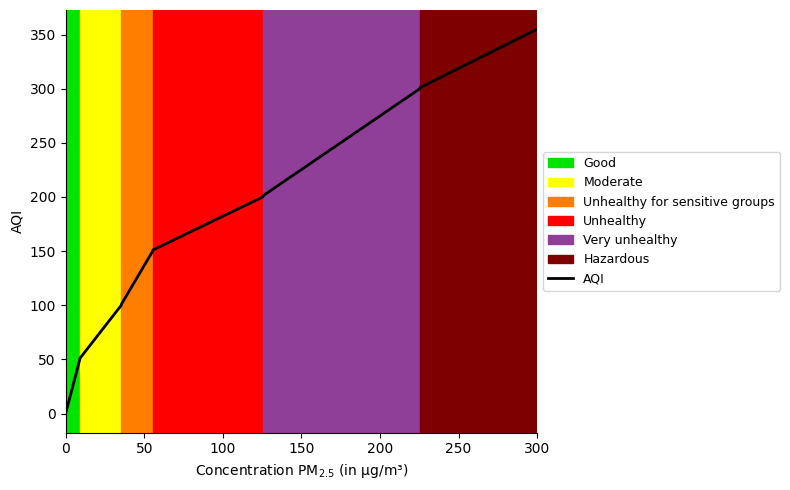

In [6]:

C_low  = np.array([0.0, 9.1, 35.5, 55.5, 125.5, 225.5])
C_high = np.array([9.0, 35.4, 55.4, 125.4, 225.4, 500.4])
I_low  = np.array([0, 51, 101, 151, 201, 301])
I_high = np.array([50, 100, 150, 200, 300, 500])

C_max = 300
C = np.arange(0, C_max + 0.05, 0.1) + 1e-15
I = np.zeros_like(C)
indx_old = 0
for i, c in enumerate(C):
    mask = (c >= C_low) & (c <= C_high)
    idx = np.flatnonzero(mask)
    j = idx[0] if len(idx) else indx_old
    I[i] = I_low[j] + (c - C_low[j]) / (C_high[j] - C_low[j]) * (I_high[j] - I_low[j])
    indx_old = j

AQI_colors = np.array([
    [0, 228, 0], [255, 255, 0], [255, 126, 0],
    [255, 0, 0], [143, 63, 151], [126, 0, 0],
]) / 255
AQI_labels = ["Good", "Moderate", "Unhealthy for sensitive groups",
              "Unhealthy", "Very unhealthy", "Hazardous"]

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(6):
    x_hi = C_high[i] if i < 5 else C_max
    ax.axvspan(C_low[i], x_hi, color=AQI_colors[i], alpha=1.0, label=AQI_labels[i])
ax.plot(C, I, "-", color=color_black, lw=2.0, label="AQI")
ax.set_xlabel("Concentration PM$_{2.5}$ (in µg/m³)")
ax.set_ylabel("AQI")
ax.set_xlim(0, C_max)
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.0, 0.5))
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


New Delhi days <=50: 11  >101: 292  >151: 175  max: 609  mean: 164.4


Beijing days <=50: 71  >101: 138  >151: 41  max: 237.0  mean: 90.8


Paris days <=50: 216  >101: 2  >151: 0  max: 113.0  mean: 48.7


Montreal days <=50: 319  >101: 1  >151: 0  max: 104.0  mean: 31.3


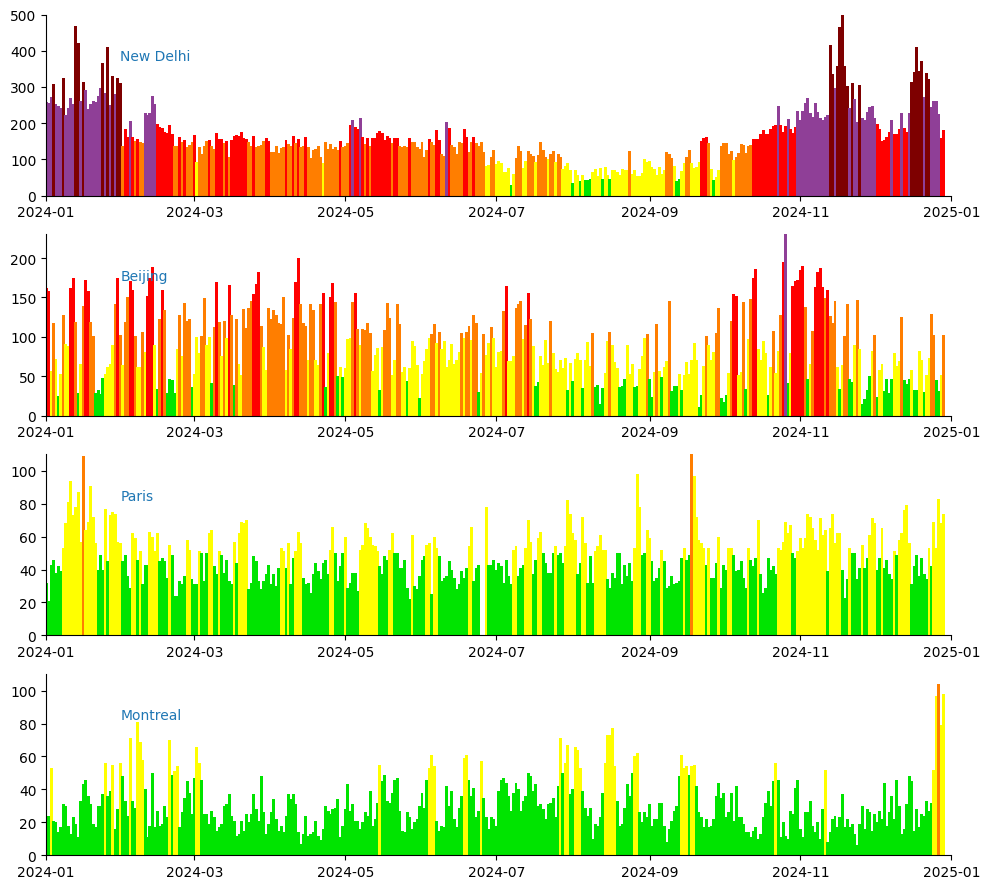

In [7]:

xl = pd.ExcelFile(f"{DATA_DIR}/chap5_world_aqi.xlsx")
city_sheets = {"New Delhi": "new-delhi", "Beijing": "beijing", "Paris": "paris", "Montreal": "montreal"}
y_max_by_city = {"New Delhi": 500, "Beijing": 230, "Paris": 110, "Montreal": 110}

def aqi_category(pm25):
    cat = np.searchsorted(I_low, pm25, side="right") - 1
    return np.clip(cat, 0, 5)

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=False)
for ax, (city, sheet) in zip(axes, city_sheets.items()):
    df = xl.parse(sheet)
    df.columns = [c.strip() for c in df.columns]
    df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")
    df = df.dropna(subset=["date", "pm25"])
    df = df.sort_values("date")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")]
    cats = aqi_category(df["pm25"].values)
    colors = AQI_colors[cats]

    print(city, "days <=50:", (df["pm25"] < 51).sum(), " >101:", (df["pm25"] > 101).sum(),
          " >151:", (df["pm25"] > 151).sum(), " max:", df["pm25"].max(),
          " mean:", round(df["pm25"].mean(), 1))

    ax.bar(df["date"], df["pm25"], color=colors, width=1.2)
    ax.text(df["date"].iloc[30], y_max_by_city[city] * 0.75, city, color=color_blue)
    ax.set_ylim(0, y_max_by_city[city])
    ax.set_xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-01-01"))
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## 3. Pollution research attention and marine-plastic sources

Relative search-engine hit counts for "[topic] pollution" + "health
effects"/"health impacts", across eight pollution types, alongside a
marine-plastic-pollution source breakdown (McKinsey Global
Institute-style). Both are literature/report-derived summary statistics
hardcoded here — there is no underlying dataset file to read.


In [8]:

topic = ["air", "biological", "chemical", "light", "noise", "plastic", "soil", "water"]
n1 = np.array([768000, 1030, 10100, 4160, 21200, 8300, 29600, 80100])   # "health effects"
n2 = np.array([281000, 486, 4950, 2300, 12900, 6870, 12900, 36200])     # "health impacts"
n3 = n1 + n2
n3[5] = 200000  # override for "plastic pollution health effects"

table_34a = pd.DataFrame({
    "Health effects (%)": 100 * n1 / n1.sum(),
    "Health impacts (%)": 100 * n2 / n2.sum(),
    "Combined (%)": 100 * n3 / n3.sum(),
}, index=topic).round(1)
table_34a


,Health effects (%),Health impacts (%),Combined (%)
air,83.3,78.6,71.6
biological,0.1,0.1,0.1
chemical,1.1,1.4,1.0
light,0.5,0.6,0.4
noise,2.3,3.6,2.3
plastic,0.9,1.9,13.7
soil,3.2,3.6,2.9
water,8.7,10.1,7.9


In [9]:

sources_34b = ["Textile fibers", "Tire particles", "City dust", "Road markings",
               "Marine coatings", "Personal care products", "Plastic pellets",
               "Road markings (secondary)", "Fishing gear", "Cosmetic microbeads",
               "Synthetic turf infill", "Total"]
x = np.array([6.67, 2.31, 4.14, 0.37, 1.36, 0.76, 1.23, 0.87, 0.35, 0.52, 0.90, 9.01])
y = 100 * x / 9.01
pd.DataFrame({"Share of total (%)": y}, index=sources_34b).round(1)


,Share of total (%)
Textile fibers,74.0
Tire particles,25.6
City dust,45.9
Road markings,4.1
Marine coatings,15.1
Personal care products,8.4
Plastic pellets,13.7
Road markings (secondary),9.7
Fishing gear,3.9
Cosmetic microbeads,5.8



## 4. The global burden of disease from air pollution

Disability-Adjusted Life Years (DALYs) and Years Lived with Disability
(YLD) attributable to ambient air pollution, by disease category (Global
Burden of Disease-style summary statistics, hardcoded here — no
underlying data file).


In [10]:

labels_34c = ["Type 2 diabetes", "COPD", "Stroke", "Cataracts", "IHD", "LRI",
              "Lung cancer", "Neonatal disorders", "Other", "Total"]
data_34c = np.array([
    [6653020, 30252], [5830818, 22780], [5028001, 10497], [2143472, 11370],
    [1248232, 16654], [198029, 1214], [99225, 214], [19482, 35], [8415, 0], [21228694, 93016],
])
YLD = data_34c[:, 0]
DALY = data_34c[:, 1] * 1e6
with np.errstate(divide="ignore", invalid="ignore"):
    DW = 365 * YLD / DALY
DW[-2] = np.nan  # this row's disability weight is undefined (zero DALY denominator)

table_34c = pd.DataFrame({
    "YLD (millions)": YLD / 1e6,
    "Share of YLD (%)": 100 * YLD / YLD[:-1].sum(),
    "DALYs (billions)": DALY / 1e9,
    "Share of DALYs (%)": 100 * DALY / DALY[:-1].sum(),
    "Disability weight (%)": 100 * DW,
}, index=labels_34c).round(2)
table_34c


,YLD (millions),Share of YLD (%),DALYs (billions),Share of DALYs (%),Disability weight (%)
Type 2 diabetes,6.65,31.34,30.25,32.52,8.03
COPD,5.83,27.47,22.78,24.49,9.34
Stroke,5.03,23.68,10.50,11.29,17.48
Cataracts,2.14,10.10,11.37,12.22,6.88
IHD,1.25,5.88,16.65,17.90,2.74
LRI,0.20,0.93,1.21,1.31,5.95
Lung cancer,0.10,0.47,0.21,0.23,16.92
Neonatal disorders,0.02,0.09,0.04,0.04,20.32
Other,0.01,0.04,0.00,0.00,NaN
Total,21.23,100.00,93.02,100.00,8.33



## 5. The economic cost of pollution, by country

Data: `chap5_world_bank_pollution.xlsx` (World Bank "Cost of the Global
Air Pollution" dataset: welfare cost of ambient (AAP) and household (HAP)
air pollution, PPP-adjusted, plus their share of GDP and of mortality vs.
morbidity burden).


In [11]:

pollution = pd.read_excel(f"{DATA_DIR}/chap5_world_bank_pollution.xlsx")
outdoor = pollution["AAP_PPP"]
indoor = pollution["HAP_PPP"]
total_share = outdoor + indoor
p_outdoor = outdoor / total_share
p_indoor = indoor / total_share
p_morbidity = pollution["MORBIDITY_SHARE"] / 100
p_mortality = 1 - p_morbidity

pollution_table = pd.DataFrame({
    "Total cost, PPP ($bn)": pollution["TOTAL_PPP"] / 1000,
    "Cost, % of GDP": pollution["GDP_SHARE"],
    "Outdoor pollution share (%)": 100 * p_outdoor,
    "Indoor pollution share (%)": 100 * p_indoor,
    "Mortality share (%)": 100 * p_mortality,
    "Morbidity share (%)": 100 * p_morbidity,
}, index=pollution["ECONOMY"])

pollution_table.dropna(subset=["Total cost, PPP ($bn)"]).sort_values(
    "Total cost, PPP ($bn)", ascending=False
).head(25).round(2)


,"Total cost, PPP ($bn)","Cost, % of GDP",Outdoor pollution share (%),Indoor pollution share (%),Mortality share (%),Morbidity share (%)
ECONOMY,,,,,,



## 6. The EU's circular-economy and waste-target implementation gap

Data: `chap5_mejino_pollution.xlsx` (waste-management/circular-economy
investment need as a share of GDP, across three EU funding-period windows:
2014-2020, 2021-2027, 2024-2030).


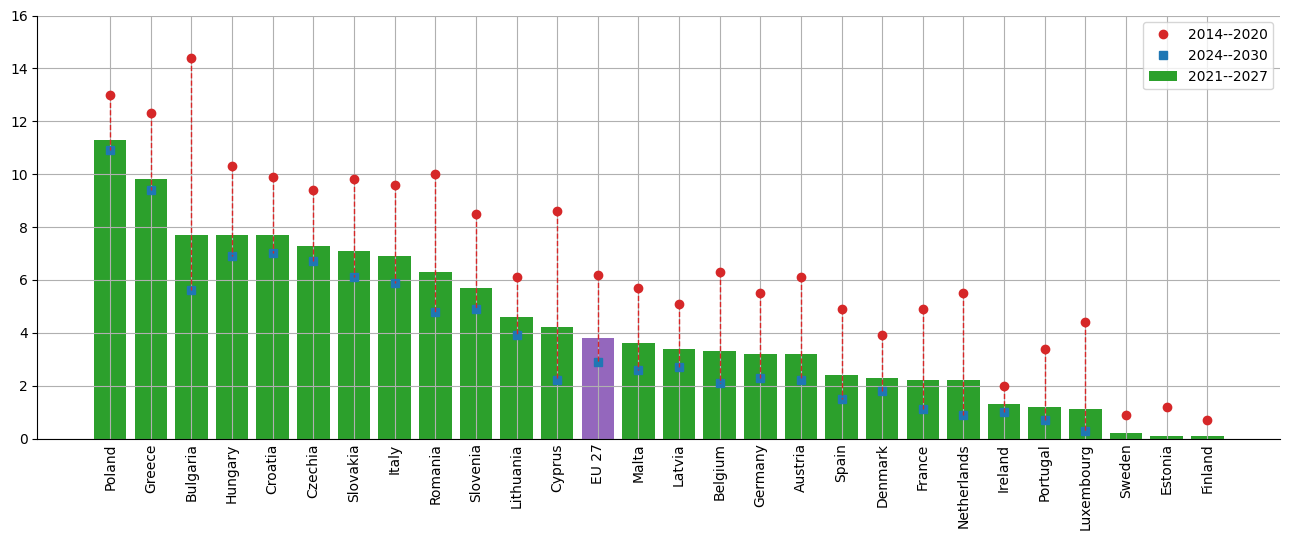

In [12]:

mejino = pd.read_excel(f"{DATA_DIR}/chap5_mejino_pollution.xlsx")
mejino = mejino.sort_values("Ratio2", ascending=False).reset_index(drop=True)
countries = mejino["Country"]
r2 = 100 * mejino["Ratio2"]  # 2021-2027
r1 = 100 * mejino["Ratio1"]  # 2014-2020
r3 = 100 * mejino["Ratio3"].where(mejino["Ratio3"] > 0.001)  # 2024-2030, mask near-zero

is_eu27 = countries == "EU 27"

fig, ax = plt.subplots(figsize=(13, 5.5))
bar_colors = np.where(is_eu27, color_violet, color_green)
ax.bar(countries, r2, color=bar_colors, label="2021--2027")
ax.plot(countries, r1, "o", color=color_red, markersize=6, label="2014--2020")
ax.plot(countries, r3, "s", color=color_blue, markersize=6, label="2024--2030")
for i in range(len(countries)):
    if pd.notna(r3.iloc[i]):
        ax.plot([countries.iloc[i]] * 2, [r1.iloc[i], r3.iloc[i]], "--", color=color_red, lw=1.0)

ax.set_ylim(0, 16)
ax.set_yticks(range(0, 17, 2))
ax.tick_params(axis="x", rotation=90, length=0)
ax.grid(axis="both")
ax.legend(fontsize=10, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## 7. Global freshwater withdrawal trends & water stress

Data: `chap5_freshwater_data.xlsx` (Our World in Data / World Bank
freshwater withdrawal series, blended across sources, plus World Bank
water-resource indicators by country).


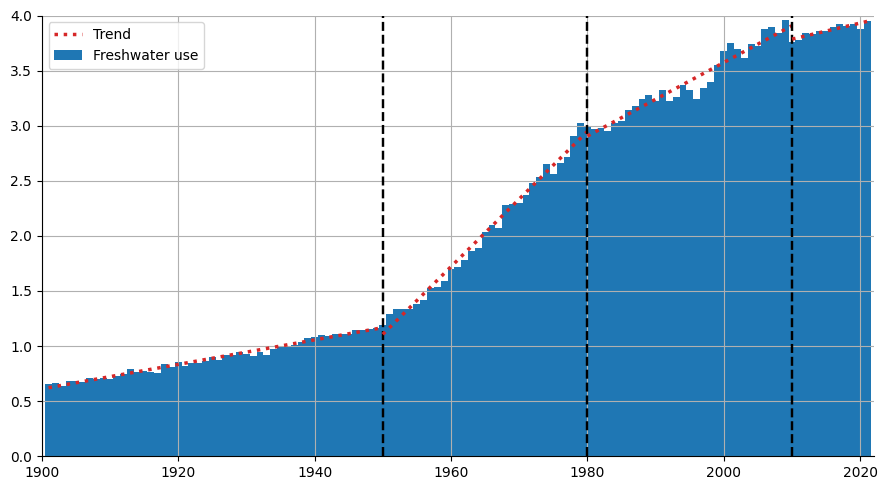

In [13]:

freshwater = pd.read_excel(f"{DATA_DIR}/chap5_freshwater_data.xlsx", sheet_name="Global Freshwater Use")
x = freshwater["Year"].values
y = freshwater["Combined"].values / 1e12

periods = [(1900, 1950), (1950, 1980), (1980, 2010), (2010, 2023)]
y_hat = np.full((len(x), len(periods)), np.nan)
for i, (a, b) in enumerate(periods):
    mask = (x >= a) & (x <= b)
    X = np.column_stack([np.ones(mask.sum()), x[mask]])
    beta = np.linalg.lstsq(X, y[mask], rcond=None)[0]
    y_hat[mask, i] = X @ beta

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, y, color=color_blue, width=1.0, label="Freshwater use")
for i, (a, b) in enumerate(periods):
    ax.plot(x, y_hat[:, i], ":", color=color_red, lw=2.5, label="Trend" if i == 0 else None)
    ax.plot([b, b], [0, 4.5], "--", color=color_black, lw=1.75)
ax.set_xlim(1900, 2022)
ax.set_ylim(0, 4.0)
ax.grid(True)
ax.legend(fontsize=10, loc="upper left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 36b — Cross-country water-resource indicators, 2000 vs. 2021

In [14]:

wb = pd.read_excel(f"{DATA_DIR}/chap5_freshwater_data.xlsx", sheet_name="World Bank Data")

selected_country = ["DZA", "ARG", "AUS", "BGD", "BRA", "CAN", "CHN", "COD", "EGY", "FRA", "GAB",
                    "DEU", "ISL", "IND", "IDN", "IRN", "ITA", "KAZ", "KOR", "LBY", "MDG", "MYS",
                    "MEX", "NLD", "NGA", "PAK", "PHL", "QAT", "RUS", "SAU", "ZAF", "ESP", "SDN",
                    "UKR", "GBR", "USA", "VNM", "WLD"]
selected_variable = ["ER.H2O.FWTL.K3", "ER.H2O.FWAG.ZS", "ER.H2O.FWIN.ZS", "ER.H2O.FWDM.ZS",
                     "ER.H2O.FWTL.ZS", "ER.H2O.INTR.PC", "ER.H2O.INTR.K3", "ER.H2O.FWST.ZS"]

wb_sub = wb[wb["Country Code"].isin(selected_country) & wb["Series Code"].isin(selected_variable)]
country_names = wb_sub.groupby("Country Code")["Country Name"].first().reindex(selected_country)

table_2000 = wb_sub.pivot_table(index="Country Code", columns="Series Code", values="YR2000")[selected_variable]
table_2021 = wb_sub.pivot_table(index="Country Code", columns="Series Code", values="YR2021")[selected_variable]

# Show only the total-withdrawal column (FWTL.K3) from 2000, alongside the
# full 8-indicator set from 2021.
water_table = pd.concat([
    table_2000[["ER.H2O.FWTL.K3"]].reindex(selected_country).add_suffix(" (2000)"),
    table_2021.reindex(selected_country).add_suffix(" (2021)"),
], axis=1)
water_table.index = country_names.values
water_table.loc["World"] = water_table.loc["World"] if "World" in water_table.index else water_table.iloc[-1]
water_table.round(1)


Series Code,ER.H2O.FWTL.K3 (2000),ER.H2O.FWTL.K3 (2021),ER.H2O.FWAG.ZS (2021),ER.H2O.FWIN.ZS (2021),ER.H2O.FWDM.ZS (2021),ER.H2O.FWTL.ZS (2021),ER.H2O.INTR.PC (2021),ER.H2O.INTR.K3 (2021),ER.H2O.FWST.ZS (2021)
Algeria,5.6,9.8,63.8,1.8,34.4,87.2,251.3,11.2,137.9
Argentina,30.4,37.7,73.9,10.6,15.5,12.9,6444.2,292.0,10.5
Australia,21.7,11.4,67.8,18.1,14.0,2.3,19154.8,492.0,4.6
Bangladesh,NaN,35.9,87.8,2.1,10.0,34.2,626.3,105.0,5.7
Brazil,56.1,67.3,61.3,14.5,24.2,1.2,27015.0,5661.0,1.5
Canada,41.9,36.3,11.4,74.2,14.4,1.3,74529.6,2850.0,3.7
China,550.9,568.5,62.1,17.7,20.1,20.2,1991.6,2812.9,41.5
"Congo, Dem. Rep.",0.6,0.7,10.5,21.5,68.0,0.1,9077.3,900.0,0.2
"Egypt, Arab Rep.",57.0,77.5,79.2,7.0,13.9,7750.0,9.0,1.0,141.2
France,32.7,24.7,13.9,64.3,21.7,12.3,2948.0,200.0,21.6



### 36c — Freshwater intensity index, selected countries (1961=100)

A smoothing spline (`scipy`'s `UnivariateSpline`) is applied to China's
series only, to smooth out reporting-methodology breaks; the smoothing
parameter is chosen by inspection rather than fit to any reference curve,
so the resulting curve should be read as a qualitative smoothing rather
than a numerically precise one.


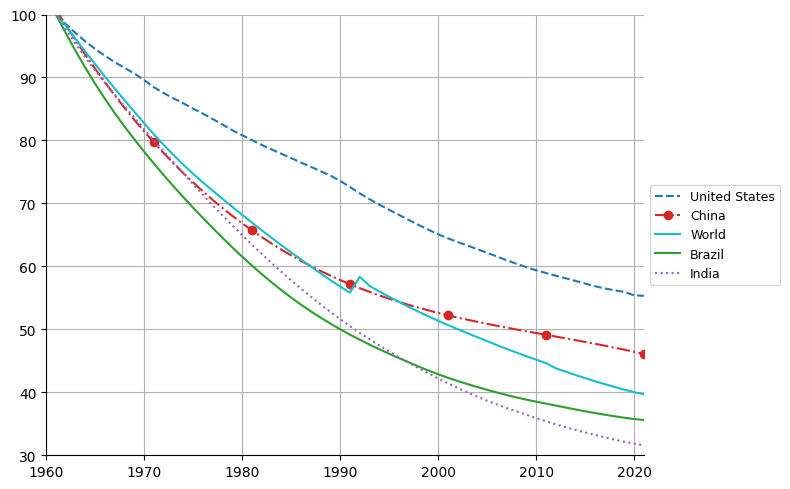

In [15]:

renewable = pd.read_excel(f"{DATA_DIR}/chap5_freshwater_data.xlsx", sheet_name="Renewable")
year_cols = [f"YR{y}" for y in range(1961, 2022)]
t = np.arange(1961, 2022)

selected_country = ["USA", "CHN", "WLD", "BRA", "IND"]
sub = renewable[renewable["Country Code"].isin(selected_country)].drop_duplicates("Country Code")
sub = sub.set_index("Country Code").reindex(selected_country)
data = sub[year_cols].values.astype(float)
data = 100 * data / data[:, [0]]

fig, ax = plt.subplots(figsize=(8, 5))
styles = ["--", "-.", "-", "-", ":"]
colors = [color_blue, color_red, color_teal, color_green, color_violet]
for i, (code_, name) in enumerate(zip(selected_country, sub["Country Name"])):
    y = data[i]
    if code_ == "CHN":
        from scipy.interpolate import UnivariateSpline
        spline = UnivariateSpline(t, y, s=len(t) * 2)
        y = spline(t)
    ax.plot(t, y, styles[i], color=colors[i], lw=1.5, label=name,
            marker="o" if code_ == "CHN" else None,
            markevery=10 if code_ == "CHN" else None)
ax.set_xlim(1960, 2021)
ax.set_ylim(30, 100)
ax.grid(True)
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.0, 0.5))
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## Summary

This notebook covered pollution and environmental-health themes from
Chapter 5's biodiversity case study: dose-response and toxicological
threshold theory (with several missing custom `drc*`-style functions
reimplemented from the standard model families they are named after and
flagged as such), the US EPA Air Quality Index applied to six cities' real
PM2.5 records, literature-derived pollution-source and disease-burden
summary statistics, the World Bank's economic cost-of-pollution dataset,
the EU's circular-economy investment gap, and global/cross-country
freshwater-use trends.

No new packaging candidates: the dose-response functions are illustrative
reimplementations of missing custom code rather than something this
book's later chapters would plausibly reuse, and every other computation
here is a one-off table/chart tied to a specific dataset's layout.

Next: the final Chapter 5 biodiversity notebook covers bioeconomic and
fisheries models — logistic growth with harvesting, predator-prey
dynamics, multi-species competition, and real fisheries/wildlife-population
data.
